In [3]:
!pip install deepxde

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.3/192.3 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 12.4 MB/s eta 0:00:00


In [4]:
import deepxde as dde
import numpy as np
from deepxde.backend import tf

No backend selected.
Finding available backend...


Using backend: tensorflow.compat.v1
Other supported backends: tensorflow, pytorch, jax, paddle.
paddle supports more examples now and is recommended.
Instructions for updating:
non-resource variables are not supported in the long term


Found tensorflow.compat.v1
Setting the default backend to "tensorflow.compat.v1". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


Enable just-in-time compilation with XLA.



In [6]:
def create_model(lambda_initial):
    lambda_var = dde.Variable(lambda_initial)
    def pde(x, u):
        x_coord = x[:, 0:1]
        y_coord = x[:, 1:2]
        t_coord = x[:, 2:3]
        u_t = dde.grad.jacobian(u, x, i=0, j=2)
        u_xx = dde.grad.hessian(u, x, i=0, j=0)
        u_yy = dde.grad.hessian(u, x, i=1, j=1)
        forcing1 = (2133 / 5000) * tf.exp(-lambda_var * t_coord) * tf.sin(11 * x_coord / 10)
        forcing2 = (7821 / 10000) * tf.exp(-lambda_var * t_coord) * tf.cos(11 * y_coord / 10)
        return u_t - 0.9 * (u_xx + u_yy) + forcing1 + forcing2

    def func_u_t0(x):
        x_coord = x[:, 0:1]
        y_coord = x[:, 1:2]
        return (3 / 5) * np.sin(11 * x_coord / 10) + (11 / 10) * np.cos(11 * y_coord / 10) + (11 / 10)

    spatial_domain = dde.geometry.Rectangle([0, -np.pi], [np.pi, np.pi])
    time_domain = dde.geometry.TimeDomain(0, 1)
    geomtime = dde.geometry.GeometryXTime(spatial_domain, time_domain)

    ic = dde.icbc.IC(geomtime, func_u_t0, lambda x, on_initial: on_initial)

    def boundary_x0(x, on_boundary):
        return on_boundary and np.isclose(x[0], 0)
    def bc_x0(x):
        t = x[:, 2:3]
        return -(33.0 * np.exp(-9.0 * t / 5.0)) / 50.0
    bc1 = dde.NeumannBC(geomtime, bc_x0, boundary_x0)

    def boundary_xpi(x, on_boundary):
        return on_boundary and np.isclose(x[0], np.pi)
    def bc_xpi(x):
        t = x[:, 2:3]
        y = x[:, 1:2]
        return (11.0 / 10.0) + (11 * np.exp(-9.0 * t / 5.0) * np.cos(11.0 * y / 10.0)) / 10.0 \
               - (3.0 * np.sqrt(5.0) * np.exp(-9.0 * t / 5.0)) / 20.0 + (3.0 * np.exp(-9.0 * t / 5.0)) / 20.0
    bc2 = dde.DirichletBC(geomtime, bc_xpi, boundary_xpi)

    def boundary_ympi(x, on_boundary):
        return on_boundary and np.isclose(x[1], -np.pi)
    def bc_ympi(x):
        t = x[:, 2:3]
        x_coord = x[:, 0:1]
        return (11.0 / 10.0) + (3.0 * np.exp(-9.0 * t / 5.0) * np.sin(11.0 * x_coord / 10.0)) / 5.0 \
               - 11.0 * np.sqrt((np.sqrt(5.0) / 8.0) + (5.0 / 8.0)) * np.exp(-9.0 * t / 5.0) / 10
    bc3 = dde.DirichletBC(geomtime, bc_ympi, boundary_ympi)

    def boundary_yppi(x, on_boundary):
        return on_boundary and np.isclose(x[1], np.pi)
    def bc_yppi(x):
        t = x[:, 2:3]
        return -121.0 * np.exp(-9.0 * t / 5.0) / 400.0 + 121.0 * np.sqrt(5.0) * np.exp(-9.0 * t / 5.0) / 400.0
    bc4 = dde.NeumannBC(geomtime, bc_yppi, boundary_yppi)


    data_measure = np.load("var-11.npz")
    xyt = data_measure["xyt"]
    u_data = data_measure["u"]
    data_bc = dde.PointSetBC(xyt, u_data, component=0)


    bcs = [ic, bc1, bc2, bc3, bc4, data_bc]


    data = dde.data.TimePDE(
        geomtime,
        pde,
        bcs,
        num_domain=5000,
        num_boundary=200,
        num_initial=100,
    )

    layer_size = [3] + [32] * 4 + [1]
    net = dde.nn.FNN(layer_size, "tanh", "Glorot uniform")

    model = dde.Model(data, net)
    model.compile("adam", lr=0.001, external_trainable_variables=[lambda_var])
    return model, lambda_var

In [7]:
phase1_iterations = 3000
phase2_iterations = 50000
phase3_iterations = 100000

initial_guesses = [-2.0, 0.0, 2.0]
initial_guesses_1=-2.0
initial_guesses_2=0.0
initial_guesses_3=2.0
final_lambda_values = []

guess λ = -2.0 training
Compiling model...
Building feed-forward neural network...
'build' took 0.069632 s

'compile' took 1.114779 s

iteration 3000 times， lr=1e-3
Training model...

Step      Train loss                                                                Test loss                                                                 Test metric
0         [4.54e+00, 1.77e+00, 2.73e-02, 6.47e-01, 1.39e+00, 2.59e-02, 1.20e+00]    [4.54e+00, 1.77e+00, 2.73e-02, 6.47e-01, 1.39e+00, 2.59e-02, 1.20e+00]    []  
0 [-2.00e+00]
100 [-1.91e+00]
200 [-1.86e+00]
300 [-1.81e+00]
400 [-1.76e+00]
500 [-1.72e+00]
600 [-1.67e+00]
700 [-1.63e+00]
800 [-1.59e+00]
900 [-1.55e+00]
1000      [1.36e-01, 3.76e-02, 9.43e-03, 1.72e-02, 1.14e-02, 3.78e-03, 2.25e-01]    [1.36e-01, 3.76e-02, 9.43e-03, 1.72e-02, 1.14e-02, 3.78e-03, 2.25e-01]    []  
1000 [-1.51e+00]
1100 [-1.47e+00]
1200 [-1.43e+00]
1300 [-1.39e+00]
1400 [-1.35e+00]
1500 [-1.32e+00]
1600 [-1.28e+00]
1700 [-1.24e+00]
1800 [-1.21e+00]
1900 [-1.

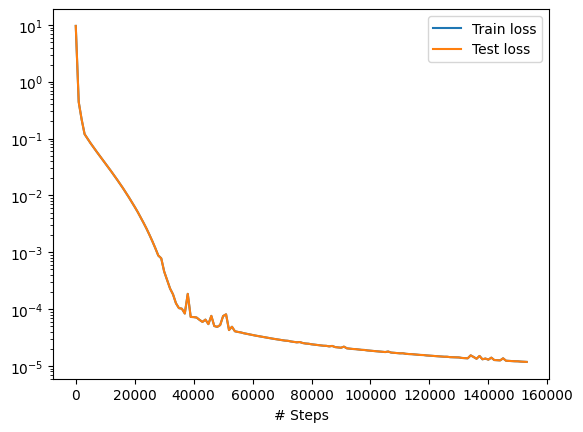

In [8]:

print("guess λ =", initial_guesses_1, "training")
model, lambda_var = create_model(initial_guesses_1)

print("iteration {} times， lr=1e-3".format(phase1_iterations))
phase1_callback = dde.callbacks.VariableValue(lambda_var, period=100)
model.train(iterations=phase1_iterations, callbacks=[phase1_callback])

print("iteration {} times， lr=1e-4".format(phase2_iterations))
model.compile("adam", lr=1e-4, external_trainable_variables=[lambda_var])
phase2_callback = dde.callbacks.VariableValue(lambda_var, period=1000)
model.train(iterations=phase2_iterations, callbacks=[phase2_callback])

print("iteration {} times， lr=1e-5".format(phase3_iterations))
model.compile("adam", lr=1e-5, external_trainable_variables=[lambda_var])
phase3_callback = dde.callbacks.VariableValue(lambda_var, period=1000)
model.train(iterations=phase3_iterations, callbacks=[phase3_callback])

final_val = model.sess.run(lambda_var)
final_lambda_values.append(final_val)
print("guess λ =", initial_guesses_1, "after training λ =", final_val)

dde.saveplot(model.losshistory, model.train_state, issave=True, isplot=True)


guess λ = 0.0 training
Compiling model...
Building feed-forward neural network...
'build' took 0.071731 s

'compile' took 0.855104 s

iteration 3000 times， lr=1e-3
Training model...

Step      Train loss                                                                Test loss                                                                 Test metric
0         [3.01e-01, 1.77e+00, 2.74e-02, 6.01e-01, 1.33e+00, 3.28e-02, 1.20e+00]    [3.01e-01, 1.77e+00, 2.74e-02, 6.01e-01, 1.33e+00, 3.28e-02, 1.20e+00]    []  
0 [0.00e+00]
100 [8.53e-02]
200 [1.30e-01]
300 [1.67e-01]
400 [2.02e-01]
500 [2.39e-01]
600 [2.74e-01]
700 [3.10e-01]
800 [3.46e-01]
900 [3.83e-01]
1000      [8.78e-03, 4.85e-03, 1.06e-03, 1.32e-03, 7.41e-04, 1.03e-03, 6.57e-03]    [8.78e-03, 4.85e-03, 1.06e-03, 1.32e-03, 7.41e-04, 1.03e-03, 6.57e-03]    []  
1000 [4.19e-01]
1100 [4.56e-01]
1200 [4.92e-01]
1300 [5.28e-01]
1400 [5.64e-01]
1500 [5.99e-01]
1600 [6.33e-01]
1700 [6.67e-01]
1800 [7.00e-01]
1900 [7.33e-01]
2000      [3.

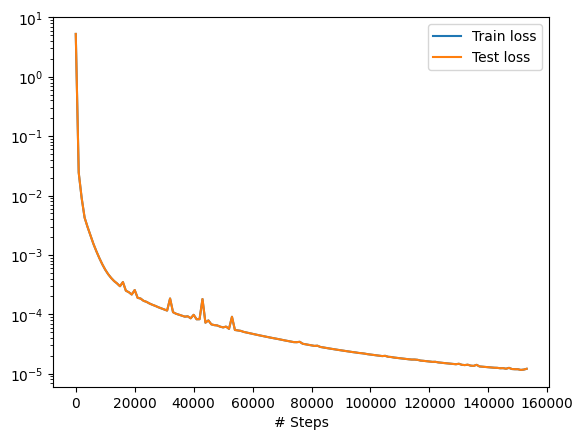

In [9]:

print("guess λ =", initial_guesses_2, "training")
model, lambda_var = create_model(initial_guesses_2)

print("iteration {} times， lr=1e-3".format(phase1_iterations))
phase1_callback = dde.callbacks.VariableValue(lambda_var, period=100)
model.train(iterations=phase1_iterations, callbacks=[phase1_callback])

print("iteration {} times， lr=1e-4".format(phase2_iterations))
model.compile("adam", lr=1e-4, external_trainable_variables=[lambda_var])
phase2_callback = dde.callbacks.VariableValue(lambda_var, period=1000)
model.train(iterations=phase2_iterations, callbacks=[phase2_callback])

print("iteration {} times， lr=1e-5".format(phase3_iterations))
model.compile("adam", lr=1e-5, external_trainable_variables=[lambda_var])
phase3_callback = dde.callbacks.VariableValue(lambda_var, period=1000)
model.train(iterations=phase3_iterations, callbacks=[phase3_callback])

final_val = model.sess.run(lambda_var)
final_lambda_values.append(final_val)
print("guess λ =", initial_guesses_2, "after training λ =", final_val)

dde.saveplot(model.losshistory, model.train_state, issave=True, isplot=True)


guess λ = 2.0 training
Compiling model...
Building feed-forward neural network...
'build' took 0.067024 s

'compile' took 0.910675 s

iteration 3000 times， lr=1e-3
Training model...

Step      Train loss                                                                Test loss                                                                 Test metric
0         [1.09e-01, 1.77e+00, 2.03e-02, 5.75e-01, 1.44e+00, 3.18e-02, 1.20e+00]    [1.09e-01, 1.77e+00, 2.03e-02, 5.75e-01, 1.44e+00, 3.18e-02, 1.20e+00]    []  
0 [2.00e+00]
100 [2.09e+00]
200 [2.12e+00]
300 [2.12e+00]
400 [2.08e+00]
500 [2.04e+00]
600 [2.00e+00]
700 [1.97e+00]
800 [1.93e+00]
900 [1.90e+00]
1000      [4.68e-03, 3.92e-03, 7.85e-04, 1.08e-03, 5.79e-04, 1.09e-03, 1.47e-04]    [4.68e-03, 3.92e-03, 7.85e-04, 1.08e-03, 5.79e-04, 1.09e-03, 1.47e-04]    []  
1000 [1.88e+00]
1100 [1.85e+00]
1200 [1.83e+00]
1300 [1.81e+00]
1400 [1.80e+00]
1500 [1.78e+00]
1600 [1.77e+00]
1700 [1.76e+00]
1800 [1.75e+00]
1900 [1.74e+00]
2000      [1.

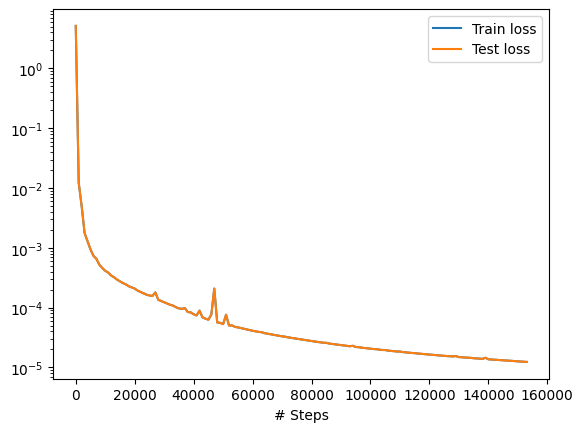

In [10]:

print("guess λ =", initial_guesses_3, "training")
model, lambda_var = create_model(initial_guesses_3)

print("iteration {} times， lr=1e-3".format(phase1_iterations))
phase1_callback = dde.callbacks.VariableValue(lambda_var, period=100)
model.train(iterations=phase1_iterations, callbacks=[phase1_callback])

print("iteration {} times， lr=1e-4".format(phase2_iterations))
model.compile("adam", lr=1e-4, external_trainable_variables=[lambda_var])
phase2_callback = dde.callbacks.VariableValue(lambda_var, period=1000)
model.train(iterations=phase2_iterations, callbacks=[phase2_callback])

print("iteration {} times， lr=1e-5".format(phase3_iterations))
model.compile("adam", lr=1e-5, external_trainable_variables=[lambda_var])
phase3_callback = dde.callbacks.VariableValue(lambda_var, period=1000)
model.train(iterations=phase3_iterations, callbacks=[phase3_callback])

final_val = model.sess.run(lambda_var)
final_lambda_values.append(final_val)
print("guess λ =", initial_guesses_3, "after training λ =", final_val)

dde.saveplot(model.losshistory, model.train_state, issave=True, isplot=True)


Из этого мы видим, что для предполагаемой лямбды = -2,0, 0,0, 2,0 все они сходятся примерно к -0,45, что можно считать соответствующим требованиям.

После пяти вычислений мы видим, что максимальная разница в значении лямбды составляет менее +-0,5, поэтому можно сказать, что она сошлась. Возьмем среднее значение:

In [11]:
# λ = 1.799241
# λ = 1.8003685
# λ = 1.80057


lambda_0 = 0
lambda_0 = (1.799241+1.8003685+1.80057)/3

In [12]:
lambda_0

1.8000598333333333